In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Directory kernel:", Path.cwd())
print("Project root:", project_root)
print("Modulo trovato:", (project_root / "funcs" / "climate_funcs.py").exists())

Directory kernel: /Users/anvi/Desktop/climate_science/notebook
Project root: /Users/anvi/Desktop/climate_science
Modulo trovato: True


In [4]:
%load_ext autoreload
%autoreload 2

from funcs.climate_funcs import (
    load_gistemp,
    make_features,
    fit_inference_model,
    fit_prediction_models,
)

In [ ]:
climate = load_gistemp()
climate.head()

,year,month_name,anomaly,month,date
0,1880,Jan,-0.19,1,1880-01-01
1,1880,Feb,-0.25,2,1880-02-01
2,1880,Mar,-0.09,3,1880-03-01
3,1880,Apr,-0.16,4,1880-04-01
4,1880,May,-0.10,5,1880-05-01


In [6]:
climate_ml = make_features(
    climate,
    n_lags=12,
)
climate_ml.head()

,year,month_name,anomaly,month,date,t_years,sin_month,cos_month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
0,1881,Jan,-0.20,1,1881-01-01,1.002074,0.500000,8.660254e-01,-0.18,-0.22,-0.24,-0.15,-0.10,-0.19,-0.21,-0.10,-0.16,-0.09,-0.25,-0.19
1,1881,Feb,-0.14,2,1881-02-01,1.086949,0.866025,5.000000e-01,-0.20,-0.18,-0.22,-0.24,-0.15,-0.10,-0.19,-0.21,-0.10,-0.16,-0.09,-0.25
2,1881,Mar,0.03,3,1881-03-01,1.163610,1.000000,6.123234e-17,-0.14,-0.20,-0.18,-0.22,-0.24,-0.15,-0.10,-0.19,-0.21,-0.10,-0.16,-0.09
3,1881,Apr,0.05,4,1881-04-01,1.248486,0.866025,-5.000000e-01,0.03,-0.14,-0.20,-0.18,-0.22,-0.24,-0.15,-0.10,-0.19,-0.21,-0.10,-0.16
4,1881,May,0.06,5,1881-05-01,1.330623,0.500000,-8.660254e-01,0.05,0.03,-0.14,-0.20,-0.18,-0.22,-0.24,-0.15,-0.10,-0.19,-0.21,-0.10


In [7]:
inference = fit_inference_model(climate_ml)

print(
    f"Trend stimato: "
    f"{inference['trend_degC_per_year']:.5f} °C/anno"
)

print(
    f"Trend stimato: "
    f"{inference['trend_degC_per_century']:.3f} °C/secolo"
)

print(f"R²: {inference['r2']:.3f}")

print(
    f"Deviazione standard dei residui ε: "
    f"{inference['residual_std_degC']:.3f} °C"
)


Trend stimato: 0.00847 °C/anno
Trend stimato: 0.847 °C/secolo
R²: 0.720
Deviazione standard dei residui ε: 0.222 °C


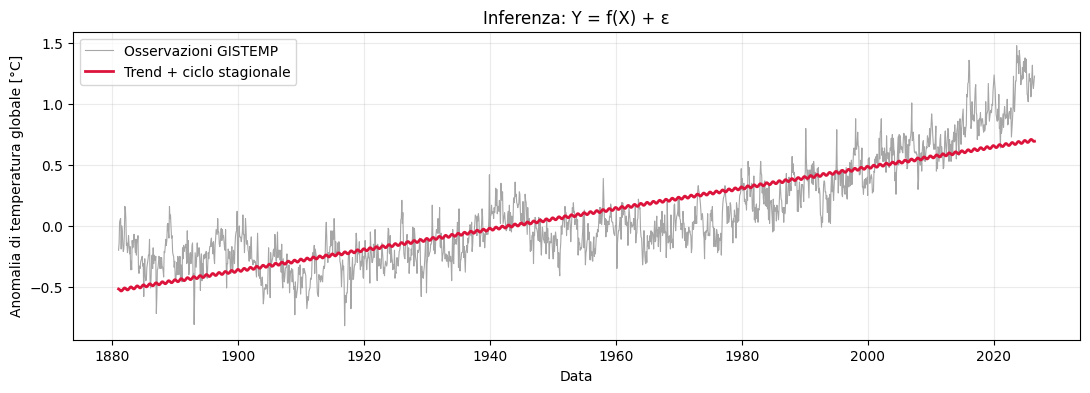

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    inference["data"]["date"],
    inference["data"]["anomaly"],
    color="0.65",
    linewidth=0.8,
    label="Osservazioni GISTEMP",
)

ax.plot(
    inference["data"]["date"],
    inference["fitted"],
    color="crimson",
    linewidth=2.0,
    label="Trend + ciclo stagionale",
)

ax.set_xlabel("Data")
ax.set_ylabel("Anomalia di temperatura globale [°C]")
ax.set_title("Inferenza: Y = f(X) + ε")
ax.grid(alpha=0.25)
ax.legend()

plt.show()


In [9]:
prediction = fit_prediction_models(
    climate_ml,
    train_fraction=0.80,
    random_state=42,
)

prediction["metrics"]

,MAE_degC,RMSE_degC,R2
polynomial,0.099831,0.124418,0.768994
random_forest,0.376436,0.449226,-2.011519


In [10]:
prediction["random_forest_importance"].head(10)

lag_1      1.838161e-02
month      1.709455e-02
lag_2      1.149809e-02
lag_7      3.083074e-03
lag_3      2.954652e-03
lag_9      9.275459e-04
lag_8      5.268466e-04
lag_4      1.161834e-04
t_years   -8.881784e-17
lag_6     -1.794169e-03
Name: permutation_importance, dtype: float64

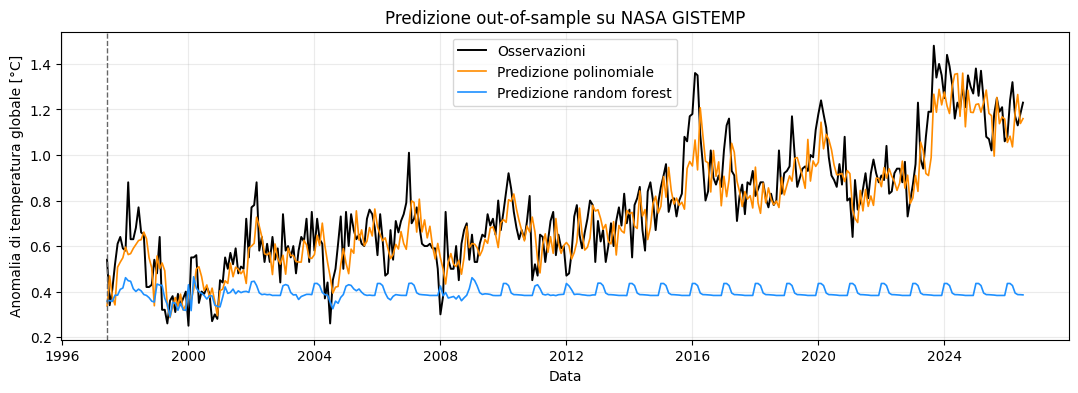

In [11]:
test = prediction["test"]

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    test["date"],
    test["anomaly"],
    color="black",
    linewidth=1.4,
    label="Osservazioni",
)

ax.plot(
    test["date"],
    prediction["predictions"]["polynomial"],
    color="darkorange",
    linewidth=1.2,
    label="Predizione polinomiale",
)

ax.plot(
    test["date"],
    prediction["predictions"]["random_forest"],
    color="dodgerblue",
    linewidth=1.2,
    label="Predizione random forest",
)

ax.axvline(
    test["date"].iloc[0],
    color="0.4",
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel("Data")
ax.set_ylabel("Anomalia di temperatura globale [°C]")
ax.set_title("Predizione out-of-sample su NASA GISTEMP")
ax.grid(alpha=0.25)
ax.legend()

plt.show()
